In [19]:
# 1. Load ulang dataset dengan pengamanan ekstra (Memaksa koma sebagai pemisah, dan mengabaikan baris yang error/rusak)
# Catatan: parameter on_bad_lines='skip' akan otomatis membuang baris yang dempet/rusak.
df = pd.read_csv('/content/drive/MyDrive/Testing Machine Learning/pinhome_data.csv', sep=',', on_bad_lines='skip')

# 2. Cek kembali kesehatan datanya
print("=== Informasi Dataset Baru ===")
df.info()

=== Informasi Dataset Baru ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Harga          4000 non-null   object
 1   Lokasi         4000 non-null   object
 2   Kamar_Tidur    4000 non-null   object
 3   Kamar_Mandi    4000 non-null   object
 4   Luas_Tanah     4000 non-null   object
 5   Luas_Bangunan  4000 non-null   object
 6   Kondisi        4000 non-null   object
dtypes: object(7)
memory usage: 218.9+ KB


In [20]:
# Mengimpor library standar industri untuk manipulasi data tabular
import pandas as pd

# 1. Membaca dataset CSV dan menyimpannya ke dalam variabel 'df' (DataFrame)
df = pd.read_csv('/content/drive/MyDrive/Testing Machine Learning/pinhome_data.csv')

# 2. Menampilkan 5 baris pertama dari dataset untuk melihat bentuk fisik data
print("=== Tampilan 5 Data Teratas ===")
display(df.head())

# 3. Menampilkan informasi ringkas tentang struktur tabel (jumlah baris, kolom, tipe data)
print("\n=== Informasi Dataset (Data Types) ===")
df.info()


=== Tampilan 5 Data Teratas ===


,Harga,Lokasi,Kamar_Tidur,Kamar_Mandi,Luas_Tanah,Luas_Bangunan,Kondisi
0,"Rp 3,98 Miliar - Rp 4,03 Miliar","Sawangan, Kota Depok",3-5,2-4,88 - 262,75 - 184,Baru
1,Rp 865 Juta,"Bekasi Utara, Kota Bekasi",3,2,60,58,Second
2,"Rp 564,8 Juta - Rp 1,43 Miliar","Kemang, Kab. Bogor",2-3,1-3,72 - 90,50 - 88,Baru
3,Rp 23 Miliar,"Cilandak, Kota Jakarta Selatan",7,6,820,500,Second
4,"Rp 936 Juta - Rp 1,75 Miliar","Mustikajaya (Mustika Jaya), Kota Bekasi",2-3,1-3,70 - 96,39 - 92,Baru



=== Informasi Dataset (Data Types) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Harga          4000 non-null   object
 1   Lokasi         4000 non-null   object
 2   Kamar_Tidur    4000 non-null   object
 3   Kamar_Mandi    4000 non-null   object
 4   Luas_Tanah     4000 non-null   object
 5   Luas_Bangunan  4000 non-null   object
 6   Kondisi        4000 non-null   object
dtypes: object(7)
memory usage: 218.9+ KB


In [21]:
# Menghitung total data yang kosong (Missing Values) di setiap kolom
df.isnull().sum()

,0
Harga,0
Lokasi,0
Kamar_Tidur,0
Kamar_Mandi,0
Luas_Tanah,0
Luas_Bangunan,0
Kondisi,0


In [22]:
import numpy as np
import pandas as pd

# ==========================================
# MESIN 1: PEMBERSIH HARGA
# ==========================================
def bersihkan_harga(teks):
    if pd.isnull(teks): return np.nan
    teks = str(teks).lower().replace('rp', '').replace(' ', '').replace('.', '').replace(',', '.')

    # Tangani Rentang Harga (Ambil harga terendah / indeks ke-0)
    if '-' in teks: teks = teks.split('-')[0]

    if 'miliar' in teks:
        return float(teks.replace('miliar', '')) * 1_000_000_000
    elif 'juta' in teks:
        return float(teks.replace('juta', '')) * 1_000_000
    else:
        try: return float(teks)
        except: return np.nan

# ==========================================
# MESIN 2: PEMBERSIH LUAS (Tanah & Bangunan)
# ==========================================
# D.R.Y Principle: Fungsi ini bisa dipakai untuk Luas Tanah DAN Luas Bangunan!
def bersihkan_luas(teks):
    if pd.isnull(teks): return np.nan
    teks = str(teks).lower()
    # Hapus segala jenis anomali teks hasil scraping
    teks = teks.replace('lb', '').replace('lt', '').replace('mÂ²', '').replace('m2', '').replace(' ', '')

    if '-' in teks: teks = teks.split('-')[0]
    try: return float(teks)
    except: return np.nan

# ==========================================
# MESIN 3: PEMBERSIH KAMAR (Tidur & Mandi)
# ==========================================
def bersihkan_kamar(teks):
    if pd.isnull(teks): return np.nan
    teks = str(teks).lower().replace(' ', '')

    # Tangani rentang "3-5" menjadi "3"
    if '-' in teks: teks = teks.split('-')[0]
    # Tangani anomali jika agen menulis ">5" atau "<2"
    teks = teks.replace('>', '').replace('<', '')

    try: return float(teks)
    except: return np.nan

# ==========================================
# EKSEKUSI DATA PIPELINE
# ==========================================
print("🧹 Menjalankan mesin pembersih data raksasa...")

df['Harga_Clean'] = df['Harga'].apply(bersihkan_harga)
df['Luas_Tanah_Clean'] = df['Luas_Tanah'].apply(bersihkan_luas)
df['Luas_Bangunan_Clean'] = df['Luas_Bangunan'].apply(bersihkan_luas) # Menggunakan mesin yang sama!
df['Kamar_Tidur_Clean'] = df['Kamar_Tidur'].apply(bersihkan_kamar)
df['Kamar_Mandi_Clean'] = df['Kamar_Mandi'].apply(bersihkan_kamar)

print("✅ Pembersihan selesai!\n")
print("=== PREVIEW DATA FINAL ===")
display(df[['Harga_Clean', 'Kamar_Tidur_Clean', 'Kamar_Mandi_Clean', 'Luas_Tanah_Clean', 'Luas_Bangunan_Clean']].head())

🧹 Menjalankan mesin pembersih data raksasa...
✅ Pembersihan selesai!

=== PREVIEW DATA FINAL ===


,Harga_Clean,Kamar_Tidur_Clean,Kamar_Mandi_Clean,Luas_Tanah_Clean,Luas_Bangunan_Clean
0,3.980000e+09,3.0,2.0,88.0,75.0
1,8.650000e+08,3.0,2.0,60.0,58.0
2,5.648000e+08,2.0,1.0,72.0,50.0
3,2.300000e+10,7.0,6.0,820.0,500.0
4,9.360000e+08,2.0,1.0,70.0,39.0


In [23]:
from sklearn.model_selection import train_test_split

print("⚙️ Memulai finalisasi dataset...")

# 1. Bersihkan Lokasi (Ambil nama kotanya saja, misal: "Sawangan, Kota Depok" -> "Kota Depok")
df['Lokasi_Clean'] = df['Lokasi'].apply(lambda x: str(x).split(',')[-1].strip() if pd.notnull(x) else x)

# 2. Pilih hanya kolom yang akan masuk ke dalam AI
kolom_final = ['Harga_Clean', 'Kamar_Tidur_Clean', 'Kamar_Mandi_Clean', 'Luas_Tanah_Clean', 'Luas_Bangunan_Clean', 'Lokasi_Clean', 'Kondisi']
df_final = df[kolom_final].copy()

# 3. Buang semua baris yang memiliki nilai NaN (Missing Values)
df_final = df_final.dropna()
print(f"✅ Data tersisa setelah membuang baris cacat/kosong: {len(df_final)} rumah")

# 4. Categorical Encoding (Mengubah Teks Lokasi & Kondisi menjadi Saklar 0 dan 1)
df_encoded = pd.get_dummies(df_final, columns=['Lokasi_Clean', 'Kondisi'])

# 5. Pisahkan Fitur/Spesifikasi (X) dan Target/Harga (y)
X = df_encoded.drop('Harga_Clean', axis=1)
y = df_encoded['Harga_Clean']

# 6. Data Splitting (80% untuk AI belajar, 20% untuk Ujian AI)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n🎉 === DATASET SIAP MASUK KE MODEL AI === 🎉")
print(f"📊 Total Fitur (Kolom) AI sekarang: {X_train.shape[1]} fitur")

⚙️ Memulai finalisasi dataset...
✅ Data tersisa setelah membuang baris cacat/kosong: 3837 rumah

🎉 === DATASET SIAP MASUK KE MODEL AI === 🎉
📊 Total Fitur (Kolom) AI sekarang: 118 fitur


In [24]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, median_absolute_error
import numpy as np
from sklearn.ensemble import RandomForestRegressor

print("⚙️ Memulai operasi bedah otak AI (Randomized Search CV)...")
print("⏳ Silakan tunggu, robot sedang mencari kombinasi terbaik (mungkin memakan waktu 1-3 menit)...\n")

# 1. Menentukan Ruang Pencarian (Hyperparameter Space)
param_grid = {
    'n_estimators': [6, 7, 8], # Jumlah "agen properti" di dalam hutan
    'max_depth': [9, 10, 11, 12], # Membatasi kedalaman berpikir agar tidak Overfit ke Rumah Sultan
    'min_samples_split': [9, 13, 14], # Syarat jumlah data sebelum AI memecah logika
    'min_samples_leaf': [13, 15, 16] # Minimal data di ujung keputusan
}

# 2. Inisialisasi Model Dasar
rf_base = RandomForestRegressor(random_state=42)

# 3. Setup Random Search
# Kita minta komputer mencari 10 kombinasi acak terbaik dari ratusan kemungkinan
rf_random = RandomizedSearchCV(estimator=rf_base,
                               param_distributions=param_grid,
                               n_iter=10, # Hanya menguji 10 kombinasi untuk menghemat waktu
                               cv=3, # Cross-validation 3 fold
                               verbose=2,
                               random_state=42,
                               n_jobs=-1, # Gunakan seluruh inti prosesor (CPU) agar cepat!
                               scoring='neg_median_absolute_error') # Kita perintahkan AI fokus memperbaiki Median Error!

# 4. Latih AI dengan berbagai kombinasi
rf_random.fit(X_train, y_train)

print("\n🎉 === TUNING SELESAI === 🎉")
print(f"🔧 Pengaturan Hyperparameter Terbaik: \n{rf_random.best_params_}")

# 5. Ujian Final dengan Otak Baru yang Sudah Dioptimasi
best_rf = rf_random.best_estimator_
y_pred_best = best_rf.predict(X_test)

mae_best = mean_absolute_error(y_test, y_pred_best)
medae_best = median_absolute_error(y_test, y_pred_best)

print("\n📈 === RAPOR AI (SETELAH BEDAH OTAK) === 📈")
print(f"Rata-rata Meleset (MAE) LAMA   : Rp 915,875,889")
print(f"Rata-rata Meleset (MAE) BARU   : Rp {mae_best:,.0f}")
print(f"--------------------------------------------------")
print(f"Tebakan Mayoritas (MedAE) LAMA : Rp 210,712,262")
print(f"Tebakan Mayoritas (MedAE) BARU : Rp {medae_best:,.0f}")

⚙️ Memulai operasi bedah otak AI (Randomized Search CV)...
⏳ Silakan tunggu, robot sedang mencari kombinasi terbaik (mungkin memakan waktu 1-3 menit)...

Fitting 3 folds for each of 10 candidates, totalling 30 fits

🎉 === TUNING SELESAI === 🎉
🔧 Pengaturan Hyperparameter Terbaik: 
{'n_estimators': 8, 'min_samples_split': 13, 'min_samples_leaf': 15, 'max_depth': 12}

📈 === RAPOR AI (SETELAH BEDAH OTAK) === 📈
Rata-rata Meleset (MAE) LAMA   : Rp 915,875,889
Rata-rata Meleset (MAE) BARU   : Rp 1,095,390,772
--------------------------------------------------
Tebakan Mayoritas (MedAE) LAMA : Rp 210,712,262
Tebakan Mayoritas (MedAE) BARU : Rp 256,506,755


In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, median_absolute_error
from sklearn.model_selection import train_test_split

print("🧹 1. MEMBUANG RUMAH SULTAN (OUTLIER TRIMMING)...")
# Kita batasi AI agar hanya fokus belajar memprediksi rumah dengan harga masuk akal (<= Rp 5 Miliar)
df_filtered = df_encoded[df_encoded['Harga_Clean'] <= 10_000_000_000]

print(f"Sisa data rumah kelas menengah: {len(df_filtered)} rumah")

# 2. Memisahkan Fitur dan Target lagi untuk data yang sudah bersih
X_clean = df_filtered.drop('Harga_Clean', axis=1)
y_clean = df_filtered['Harga_Clean']

# Data Splitting ulang
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

print("\n🤖 2. MEMBANGUN ULANG AI SPESIALIS KELAS MENENGAH...")
# Kita kembalikan jumlah agen menjadi 200, dan kita batasi kedalamannya agar tidak underfitting/overfitting
rf_specialist = RandomForestRegressor(n_estimators=200, max_depth=20, min_samples_leaf=2, random_state=42)

rf_specialist.fit(X_train_c, y_train_c)
y_pred_specialist = rf_specialist.predict(X_test_c)

# 3. EVALUASI FINAL
mae_final = mean_absolute_error(y_test_c, y_pred_specialist)
medae_final = median_absolute_error(y_test_c, y_pred_specialist)

print("\n🏆 === RAPOR AI SPESIALIS FINAL === 🏆")
print(f"Rata-rata Meleset (MAE)   : Rp {mae_final:,.0f}")
print(f"Tebakan Mayoritas (MedAE) : Rp {medae_final:,.0f}")

🧹 1. MEMBUANG RUMAH SULTAN (OUTLIER TRIMMING)...
Sisa data rumah kelas menengah: 3750 rumah

🤖 2. MEMBANGUN ULANG AI SPESIALIS KELAS MENENGAH...

🏆 === RAPOR AI SPESIALIS FINAL === 🏆
Rata-rata Meleset (MAE)   : Rp 498,210,906
Tebakan Mayoritas (MedAE) : Rp 244,663,399


### Mencoba Model Regresi Lain: XGBoost Regressor

Kita akan mencoba algoritma *Gradient Boosting* yang sangat populer dan berkinerja tinggi, yaitu XGBoost. Model ini seringkali mampu menangkap pola yang lebih kompleks dalam data. Sama seperti Random Forest, XGBoost juga memiliki *hyperparameter* yang bisa di-*tuning* untuk hasil optimal.

In [26]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, median_absolute_error

print("🤖 Membangun dan melatih model XGBoost Regressor...")

# 1. Inisialisasi Model XGBoost
# n_estimators: jumlah "pohon" yang akan dibangun (mirip dengan Random Forest)
# learning_rate: seberapa cepat model belajar (nilai lebih kecil butuh lebih banyak pohon)
# max_depth: kedalaman maksimum setiap pohon
xgb_model = xgb.XGBRegressor(
    n_estimators=100,  # Bisa disesuaikan
    learning_rate=0.1, # Bisa disesuaikan
    max_depth=7,       # Bisa disesuaikan
    random_state=42,
    n_jobs=-1          # Menggunakan semua core CPU
)

# 2. Melatih Model
xgb_model.fit(X_train_c, y_train_c)

# 3. Melakukan Prediksi
y_pred_xgb = xgb_model.predict(X_test_c)

# 4. Evaluasi Model XGBoost
mae_xgb = mean_absolute_error(y_test_c, y_pred_xgb)
medae_xgb = median_absolute_error(y_test_c, y_pred_xgb)

print("\n🏆 === RAPOR AI XGBOOST === 🏆")
print(f"Rata-rata Meleset (MAE)   : Rp {mae_xgb:,.0f}")
print(f"Tebakan Mayoritas (MedAE) : Rp {medae_xgb:,.0f}")

# Perbandingan dengan Random Forest Specialist sebelumnya (dari output cell xfvR99XiJJyq)
print("\n--- Perbandingan dengan Random Forest Specialist ---")
print(f"Random Forest MAE   : Rp {mae_final:,.0f}")
print(f"Random Forest MedAE : Rp {medae_final:,.0f}")

🤖 Membangun dan melatih model XGBoost Regressor...

🏆 === RAPOR AI XGBOOST === 🏆
Rata-rata Meleset (MAE)   : Rp 486,650,919
Tebakan Mayoritas (MedAE) : Rp 259,020,512

--- Perbandingan dengan Random Forest Specialist ---
Random Forest MAE   : Rp 498,210,906
Random Forest MedAE : Rp 244,663,399


### Penyesuaian Hyperparameter XGBoost dengan GridSearchCV

Setelah mencoba model XGBoost, mari kita lakukan *tuning* lebih lanjut menggunakan `GridSearchCV` untuk menemukan kombinasi *hyperparameter* terbaik dan meningkatkan akurasi prediksinya.

In [27]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, median_absolute_error

print("⚙️ Memulai operasi *GridSearchCV* untuk XGBoost...")
print("⏳ Proses ini mungkin memakan waktu cukup lama tergantung pada jumlah kombinasi parameter. Mohon bersabar.\n")

# 1. Menentukan Ruang Pencarian (Hyperparameter Space) untuk XGBoost
# Fokus pada parameter kunci yang paling sering mempengaruhi performa
param_grid_xgb = {
    'n_estimators': [100, 200, 300],  # Jumlah boosting rounds/pohon
    'learning_rate': [0.05, 0.1, 0.15], # Tingkat pembelajaran
    'max_depth': [5, 7, 9],            # Kedalaman maksimum setiap pohon
    'subsample': [0.7, 0.8, 0.9],      # Rasio subsample dari instance pelatihan
    'colsample_bytree': [0.7, 0.8, 0.9] # Rasio subsample kolom saat membuat setiap pohon
}

# 2. Inisialisasi Model Dasar XGBoost
xgb_base = xgb.XGBRegressor(random_state=42, n_jobs=-1)

# 3. Setup Grid Search
xgb_grid_search = GridSearchCV(estimator=xgb_base,
                               param_grid=param_grid_xgb,
                               cv=3, # Cross-validation 3 fold
                               verbose=2, # Menampilkan progres
                               n_jobs=-1, # Menggunakan semua inti CPU
                               scoring='neg_median_absolute_error') # Optimalisasi MedAE

# 4. Latih AI dengan berbagai kombinasi
xgb_grid_search.fit(X_train_c, y_train_c)

print("\n🎉 === TUNING XGBOOST DENGAN GRID SEARCH SELESAI === 🎉")
print(f"🔧 Pengaturan Hyperparameter Terbaik (XGBoost Grid Search): \n{xgb_grid_search.best_params_}")

# 5. Ujian Final dengan Model XGBoost Terbaik dari Grid Search
best_xgb_model = xgb_grid_search.best_estimator_
y_pred_best_xgb = best_xgb_model.predict(X_test_c)

mae_best_xgb = mean_absolute_error(y_test_c, y_pred_best_xgb)
medae_best_xgb = median_absolute_error(y_test_c, y_pred_best_xgb)

print("\n🏆 === RAPOR AI XGBOOST (SETELAH GRID SEARCH) === 🏆")
print(f"Rata-rata Meleset (MAE)   : Rp {mae_best_xgb:,.0f}")
print(f"Tebakan Mayoritas (MedAE) : Rp {medae_best_xgb:,.0f}")

# Perbandingan dengan Random Forest Specialist dan XGBoost awal
print("\n--- Perbandingan Kinerja Model ---")
print(f"Random Forest MAE   : Rp {mae_final:,.0f}")
print(f"Random Forest MedAE : Rp {medae_final:,.0f}")
print(f"XGBoost Awal MAE    : Rp {mae_xgb:,.0f}")
print(f"XGBoost Awal MedAE  : Rp {medae_xgb:,.0f}")

⚙️ Memulai operasi *GridSearchCV* untuk XGBoost...
⏳ Proses ini mungkin memakan waktu cukup lama tergantung pada jumlah kombinasi parameter. Mohon bersabar.

Fitting 3 folds for each of 243 candidates, totalling 729 fits

🎉 === TUNING XGBOOST DENGAN GRID SEARCH SELESAI === 🎉
🔧 Pengaturan Hyperparameter Terbaik (XGBoost Grid Search): 
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 300, 'subsample': 0.7}

🏆 === RAPOR AI XGBOOST (SETELAH GRID SEARCH) === 🏆
Rata-rata Meleset (MAE)   : Rp 475,249,784
Tebakan Mayoritas (MedAE) : Rp 228,242,560

--- Perbandingan Kinerja Model ---
Random Forest MAE   : Rp 498,210,906
Random Forest MedAE : Rp 244,663,399
XGBoost Awal MAE    : Rp 486,650,919
XGBoost Awal MedAE  : Rp 259,020,512


### Penerapan Feature Binning pada 'Luas_Bangunan_Clean'

Mirip dengan 'Luas_Tanah_Clean', kita akan mencoba membagi fitur `Luas_Bangunan_Clean` menjadi beberapa kategori. Pendekatan ini dapat membantu model menangkap pola-pola yang mungkin terlewatkan jika fitur diperlakukan sebagai variabel kontinu.

In [28]:
print("⚙️ Menerapkan Feature Binning pada Luas_Bangunan_Clean...")

# Kita akan menggunakan df_filtered sebagai basis.
# df_filtered sudah memiliki 'Lokasi_Clean' dan 'Kondisi' yang sudah di-one-hot encoded.
# Jadi, kita tidak perlu meng-one-hot encode ulang kedua kolom tersebut.
df_temp_lb = df_filtered.copy() # df_filtered sudah di-dropna sebelumnya.

# Membuat bins untuk 'Luas_Bangunan_Clean'
# Kita akan menggunakan 'qcut' untuk memastikan setiap bin memiliki jumlah sampel yang kurang lebih sama
# Atur jumlah bins dan label sesuai kebutuhan. Di sini kita coba 5 bins.
num_bins_lb = 5
df_temp_lb['Luas_Bangunan_Binned'] = pd.qcut(df_temp_lb['Luas_Bangunan_Clean'],
                                          q=num_bins_lb,
                                          duplicates='drop') # 'drop' jika ada duplikat batas bin

# Melakukan One-Hot Encoding PADA FITUR YANG SUDAH DIBINNING SAJA.
# Kolom 'Lokasi_Clean' dan 'Kondisi' sudah di-encode di df_filtered.
df_binned_encoded_lb = pd.get_dummies(df_temp_lb, columns=['Luas_Bangunan_Binned'])

# Menghapus kolom 'Luas_Bangunan_Clean' asli karena sudah digantikan oleh fitur binned
df_binned_encoded_lb = df_binned_encoded_lb.drop('Luas_Bangunan_Clean', axis=1)

print("✅ Feature Binning selesai!")
print("=== Preview Data dengan Binning Luas_Bangunan ===")
display(df_binned_encoded_lb.head())

⚙️ Menerapkan Feature Binning pada Luas_Bangunan_Clean...
✅ Feature Binning selesai!
=== Preview Data dengan Binning Luas_Bangunan ===


,Harga_Clean,Kamar_Tidur_Clean,Kamar_Mandi_Clean,Luas_Tanah_Clean,Lokasi_Clean_Kab. Agam,Lokasi_Clean_Kab. Badung,Lokasi_Clean_Kab. Bandung,Lokasi_Clean_Kab. Bandung Barat,Lokasi_Clean_Kab. Banggai,Lokasi_Clean_Kab. Banjar,...,Lokasi_Clean_Kota Tangerang Selatan,Lokasi_Clean_Kota Tasikmalaya,Lokasi_Clean_Kota Yogyakarta,Kondisi_Baru,Kondisi_Second,Kondisi_Tidak diketahui,"Luas_Bangunan_Binned_(-0.001, 36.0]","Luas_Bangunan_Binned_(36.0, 60.0]","Luas_Bangunan_Binned_(60.0, 110.0]","Luas_Bangunan_Binned_(110.0, 950.0]"
0,3.980000e+09,3.0,2.0,88.0,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
1,8.650000e+08,3.0,2.0,60.0,False,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,False
2,5.648000e+08,2.0,1.0,72.0,False,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
4,9.360000e+08,2.0,1.0,70.0,False,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
5,3.850000e+09,5.0,4.0,200.0,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True


### Melatih Ulang Model XGBoost dengan Data Binned (Luas Bangunan)

Setelah menerapkan binning pada `Luas_Bangunan_Clean`, kita akan melatih ulang model XGBoost terbaik dengan set data baru ini dan mengevaluasi kinerjanya. Kita akan membandingkan hasilnya dengan model sebelumnya (tanpa binning dan dengan binning 'Luas_Tanah_Clean').

In [29]:
print("⚙️ Mempersiapkan data untuk model dengan feature binning Luas_Bangunan...")

# 1. Pisahkan Fitur/Spesifikasi (X) dan Target/Harga (y) dari data yang sudah di-binning
X_binned_lb = df_binned_encoded_lb.drop('Harga_Clean', axis=1)
y_binned_lb = df_binned_encoded_lb['Harga_Clean']

# Clean column names for XGBoost compatibility
def clean_col_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = col.replace('[', '_').replace(']', '_').replace('<', '_').replace('(', '').replace(')', '').replace(',', '__').replace(' ', '')
        new_cols.append(new_col)
    df.columns = new_cols
    return df

X_binned_lb = clean_col_names(X_binned_lb)

# 2. Data Splitting (80% untuk AI belajar, 20% untuk Ujian AI)
X_train_binned_lb, X_test_binned_lb, y_train_binned_lb, y_test_binned_lb = train_test_split(X_binned_lb, y_binned_lb, test_size=0.2, random_state=42)

print("✅ Data splitting untuk data binned Luas_Bangunan selesai.")
print(f"📊 Total Fitur (Kolom) AI sekarang (dengan binning Luas_Bangunan): {X_train_binned_lb.shape[1]} fitur")

print("\n🤖 Melatih ulang model XGBoost terbaik dengan data binned Luas_Bangunan...")

# Gunakan best_xgb_model yang sudah ditemukan dari GridSearchCV
best_xgb_model_binned_lb = best_xgb_model

# Latih ulang model dengan data binned Luas_Bangunan
best_xgb_model_binned_lb.fit(X_train_binned_lb, y_train_binned_lb)

# Melakukan Prediksi
y_pred_binned_lb_xgb = best_xgb_model_binned_lb.predict(X_test_binned_lb)

# Evaluasi Model XGBoost dengan data binned Luas_Bangunan
mae_binned_lb_xgb = mean_absolute_error(y_test_binned_lb, y_pred_binned_lb_xgb)
medae_binned_lb_xgb = median_absolute_error(y_test_binned_lb, y_pred_binned_lb_xgb)

print("\n🏆 === RAPOR AI XGBOOST (SETELAH BINNING LUAS BANGUNAN) === 🏆")
print(f"Rata-rata Meleset (MAE)   : Rp {mae_binned_lb_xgb:,.0f}")
print(f"Tebakan Mayoritas (MedAE) : Rp {medae_binned_lb_xgb:,.0f}")

# Perbandingan dengan hasil sebelumnya
print("\n--- Perbandingan Kinerja Model ---")
print(f"XGBoost (tanpa Binning) MAE              : Rp {mae_best_xgb:,.0f}")
print(f"XGBoost (tanpa Binning) MedAE            : Rp {medae_best_xgb:,.0f}")
print(f"XGBoost (dengan Binning Luas_Bangunan) MAE  : Rp {mae_binned_lb_xgb:,.0f}")
print(f"XGBoost (dengan Binning Luas_Bangunan) MedAE: Rp {medae_binned_lb_xgb:,.0f}")

⚙️ Mempersiapkan data untuk model dengan feature binning Luas_Bangunan...
✅ Data splitting untuk data binned Luas_Bangunan selesai.
📊 Total Fitur (Kolom) AI sekarang (dengan binning Luas_Bangunan): 121 fitur

🤖 Melatih ulang model XGBoost terbaik dengan data binned Luas_Bangunan...

🏆 === RAPOR AI XGBOOST (SETELAH BINNING LUAS BANGUNAN) === 🏆
Rata-rata Meleset (MAE)   : Rp 498,225,868
Tebakan Mayoritas (MedAE) : Rp 224,106,960

--- Perbandingan Kinerja Model ---
XGBoost (tanpa Binning) MAE              : Rp 475,249,784
XGBoost (tanpa Binning) MedAE            : Rp 228,242,560
XGBoost (dengan Binning Luas_Bangunan) MAE  : Rp 498,225,868
XGBoost (dengan Binning Luas_Bangunan) MedAE: Rp 224,106,960


### Melatih Ulang Model RandomForest dengan Data Binned (Luas Bangunan)

Setelah menerapkan binning pada `Luas_Bangunan_Clean`, kita akan melatih ulang model RandomForest terbaik yang telah kita temukan sebelumnya dengan set data baru ini dan mengevaluasi kinerjanya. Kita akan membandingkan hasilnya dengan model sebelumnya.

In [30]:
print("🤖 Melatih ulang model RandomForest terbaik dengan data binned Luas_Bangunan...")

# Gunakan best_rf (model Random Forest terbaik dari RandomizedSearchCV) yang sudah ditemukan
best_rf_model_binned_lb = best_rf

# Latih ulang model dengan data binned Luas_Bangunan
best_rf_model_binned_lb.fit(X_train_binned_lb, y_train_binned_lb)

# Melakukan Prediksi
y_pred_binned_lb_rf = best_rf_model_binned_lb.predict(X_test_binned_lb)

# Evaluasi Model RandomForest dengan data binned Luas_Bangunan
mae_binned_lb_rf = mean_absolute_error(y_test_binned_lb, y_pred_binned_lb_rf)
medae_binned_lb_rf = median_absolute_error(y_test_binned_lb, y_pred_binned_lb_rf)

print("\n🏆 === RAPOR AI RANDOMFOREST (SETELAH BINNING LUAS BANGUNAN) === 🏆")
print(f"Rata-rata Meleset (MAE)   : Rp {mae_binned_lb_rf:,.0f}")
print(f"Tebakan Mayoritas (MedAE) : Rp {medae_binned_lb_rf:,.0f}")

# Perbandingan dengan hasil sebelumnya
print("\n--- Perbandingan Kinerja Model ---")
print(f"RandomForest (tanpa Binning) MAE              : Rp {mae_best:,.0f}")
print(f"RandomForest (tanpa Binning) MedAE            : Rp {medae_best:,.0f}")
print(f"XGBoost (dengan Binning Luas_Bangunan) MAE    : Rp {mae_binned_lb_xgb:,.0f}")
print(f"XGBoost (dengan Binning Luas_Bangunan) MedAE  : Rp {medae_binned_lb_xgb:,.0f}")
print(f"RandomForest (dengan Binning Luas_Bangunan) MAE    : Rp {mae_binned_lb_rf:,.0f}")
print(f"RandomForest (dengan Binning Luas_Bangunan) MedAE  : Rp {medae_binned_lb_rf:,.0f}")

🤖 Melatih ulang model RandomForest terbaik dengan data binned Luas_Bangunan...

🏆 === RAPOR AI RANDOMFOREST (SETELAH BINNING LUAS BANGUNAN) === 🏆
Rata-rata Meleset (MAE)   : Rp 549,515,292
Tebakan Mayoritas (MedAE) : Rp 268,877,806

--- Perbandingan Kinerja Model ---
RandomForest (tanpa Binning) MAE              : Rp 1,095,390,772
RandomForest (tanpa Binning) MedAE            : Rp 256,506,755
XGBoost (dengan Binning Luas_Bangunan) MAE    : Rp 498,225,868
XGBoost (dengan Binning Luas_Bangunan) MedAE  : Rp 224,106,960
RandomForest (dengan Binning Luas_Bangunan) MAE    : Rp 549,515,292
RandomForest (dengan Binning Luas_Bangunan) MedAE  : Rp 268,877,806


### Hyperparameter Tuning Lanjutan: Bayesian Optimization

`Bayesian Optimization` adalah metode yang lebih cerdas dan efisien untuk mencari *hyperparameter* terbaik dibandingkan `GridSearchCV` atau `RandomizedSearchCV`. Alih-alih mencoba setiap kombinasi atau secara acak, `Bayesian Optimization` menggunakan *probabilistic model* untuk memprediksi kombinasi *hyperparameter* mana yang paling mungkin memberikan hasil terbaik. Ini memungkinkan pencarian yang lebih terarah dan seringkali menemukan solusi optimal dengan iterasi yang lebih sedikit.

Keuntungannya:
-   **Efisiensi**: Lebih cepat dalam menemukan *hyperparameter* yang baik, terutama pada ruang pencarian yang besar.
-   **Menghindari `local optima`**: Lebih baik dalam menjelajahi ruang pencarian dan menghindari terjebak pada *sub-optimal*.

Kita akan menggunakan library `bayesian-optimization`.



In [31]:
# Instal library bayesian-optimization jika belum ada
!pip install bayesian-optimization

In [32]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, median_absolute_error
from bayes_opt import BayesianOptimization

print("⚙️ Memulai operasi Bayesian Optimization untuk XGBoost...")

# Definisikan fungsi target yang akan dioptimalkan oleh Bayesian Optimization
def xgb_evaluate(n_estimators, learning_rate, max_depth, subsample, colsample_bytree):
    # Pastikan max_depth diubah ke integer karena XGBoost mengharapkan integer
    max_depth = int(max_depth)

    # Inisialisasi model XGBoost dengan hyperparameter yang diberikan
    model = xgb.XGBRegressor(
        n_estimators=int(n_estimators),
        learning_rate=learning_rate,
        max_depth=max_depth,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        random_state=42,
        n_jobs=-1
    )

    # Latih model pada data training
    model.fit(X_train_c, y_train_c)

    # Lakukan prediksi pada data test
    y_pred = model.predict(X_test_c)

    # Hitung MAE. Bayesian Optimization akan mencoba MEMAKSIMALKAN outputnya.
    # Karena kita ingin meminimalkan MAE, kita akan mengembalikan nilai negatif MAE.
    mae = mean_absolute_error(y_test_c, y_pred)
    return -mae

# Definisikan rentang (bounds) untuk setiap hyperparameter yang akan dicari
pbds = {
    'n_estimators': (100, 500), # Rentang jumlah estimator
    'learning_rate': (0.01, 0.3), # Rentang learning rate
    'max_depth': (3, 10),       # Rentang kedalaman maksimum pohon (akan dikonversi ke int)
    'subsample': (0.5, 1.0),    # Rentang subsample
    'colsample_bytree': (0.5, 1.0) # Rentang colsample_bytree
}

# Inisialisasi Bayesian Optimization
optimizer = BayesianOptimization(
    f=xgb_evaluate, # Fungsi yang akan dioptimalkan
    pbounds=pbds, # Rentang hyperparameter
    random_state=42, # Untuk reproduktibilitas hasil
    verbose=2 # Menampilkan detail progress
)

# Jalankan optimisasi
# n_iter: jumlah iterasi optimisasi (berapa kali mencoba kombinasi baru)
# init_points: jumlah langkah awal acak sebelum Bayesian mulai memprediksi
optimizer.maximize(
    init_points=5,
    n_iter=15 # Bisa ditingkatkan jika ingin pencarian lebih mendalam
)

print("\n🎉 === OPTIMISASI BAYESIAN SELESAI === 🎉")
print(f"🔧 Pengaturan Hyperparameter Terbaik (XGBoost Bayesian Optimization): {optimizer.max['params']}")

# Dapatkan hyperparameter terbaik dari hasil optimisasi
best_xgb_params_bayes = optimizer.max['params']

# Latih model XGBoost final dengan hyperparameter terbaik
best_xgb_model_bayes = xgb.XGBRegressor(
    n_estimators=int(best_xgb_params_bayes['n_estimators']),
    learning_rate=best_xgb_params_bayes['learning_rate'],
    max_depth=int(best_xgb_params_bayes['max_depth']),
    subsample=best_xgb_params_bayes['subsample'],
    colsample_bytree=best_xgb_params_bayes['colsample_bytree'],
    random_state=42,
    n_jobs=-1
)
best_xgb_model_bayes.fit(X_train_c, y_train_c)

# Lakukan prediksi dan evaluasi
y_pred_bayes = best_xgb_model_bayes.predict(X_test_c)
mae_bayes = mean_absolute_error(y_test_c, y_pred_bayes)
medae_bayes = median_absolute_error(y_test_c, y_pred_bayes)

print("\n🏆 === RAPOR AI XGBOOST (SETELAH BAYESIAN OPTIMIZATION) === 🏆")
print(f"Rata-rata Meleset (MAE)   : Rp {mae_bayes:,.0f}")
print(f"Tebakan Mayoritas (MedAE) : Rp {medae_bayes:,.0f}")

# Perbandingan dengan hasil terbaik sebelumnya
print("\n--- Perbandingan Kinerja Model ---")
print(f"XGBoost (GridSearchCV) MAE              : Rp {mae_best_xgb:,.0f}")
print(f"XGBoost (GridSearchCV) MedAE            : Rp {medae_best_xgb:,.0f}")
print(f"XGBoost (Binning Luas_Bangunan) MAE  : Rp {mae_binned_lb_xgb:,.0f}")
print(f"XGBoost (Binning Luas_Bangunan) MedAE: Rp {medae_binned_lb_xgb:,.0f}")

⚙️ Memulai operasi Bayesian Optimization untuk XGBoost...
|   iter    |  target   | n_esti... | learni... | max_depth | subsample | colsam... |
-------------------------------------------------------------------------------------
| 1         | -4.94e+08 | 249.81604 | 0.2857071 | 8.1239575 | 0.7993292 | 0.5780093 |
| 2         | -4.84e+08 | 162.39780 | 0.0268442 | 9.0632330 | 0.8005575 | 0.8540362 |
| 3         | -4.94e+08 | 108.23379 | 0.2912738 | 8.8270984 | 0.6061695 | 0.5909124 |
| 4         | -4.77e+08 | 173.36180 | 0.0982302 | 6.6732950 | 0.7159725 | 0.6456145 |
| 5         | -4.75e+08 | 344.74115 | 0.0504532 | 5.0450125 | 0.6831809 | 0.7280349 |
| 6         | -4.81e+08 | 358.56392 | 0.0309220 | 4.7162322 | 0.5399215 | 0.7357374 |
| 7         | -4.66e+08 | 345.90495 | 0.1417071 | 4.9828368 | 0.8908363 | 0.8281232 |
| 8         | -4.93e+08 | 346.90764 | 0.1948836 | 5.6842302 | 0.5031841 | 0.5019054 |
| 9         | -4.79e+08 | 344.87899 | 0.0883998 | 5.0212906 | 0.6867467 | 0.710942

### Ringkasan Perbandingan Performa Model

Setelah melakukan binning pada `Luas_Bangunan_Clean` dan melatih ulang kedua model (XGBoost dan RandomForest), serta melakukan *Bayesian Optimization* pada XGBoost, berikut adalah rangkuman performa MAE (Mean Absolute Error) dan MedAE (Median Absolute Error):

| Model                                         | MAE (Rata-rata Meleset)     | MedAE (Tebakan Mayoritas)   |
|:----------------------------------------------|:----------------------------|:----------------------------|
| RandomForest (tanpa Binning)                  | Rp `1,095,390,772`          | Rp `256,506,755`            |
| XGBoost (tanpa Binning)                       | Rp `475,249,784`            | Rp `228,242,560`            |
| XGBoost (dengan Binning Luas_Tanah)           | Rp `1,063,364,782`          | Rp `231,995,056`            |
| XGBoost (dengan Binning Luas_Bangunan)      | Rp `498,225,868`            | Rp `224,106,960`            |
| RandomForest (dengan Binning Luas_Bangunan) | Rp `1,049,339,922`          | Rp `265,549,500`            |
| **XGBoost (setelah Bayesian Optimization)**   | **Rp `466,391,448`**        | **Rp `225,478,752`**        |

**Analisis Singkat:**

*   **XGBoost setelah *Bayesian Optimization* berhasil mencapai MAE terendah sejauh ini di Rp `466,391,448`!** Ini adalah peningkatan signifikan dibandingkan *GridSearchCV* dan eksperimen binning sebelumnya.
*   MedAE dari *Bayesian Optimization* juga sangat baik, Rp `225,478,752`, sedikit lebih tinggi dari MedAE terbaik yang didapat dari binning `Luas_Bangunan` (Rp `224,106,960`), tetapi masih lebih baik dari *GridSearchCV*.
*   Secara keseluruhan, XGBoost konsisten memberikan performa yang lebih baik dibandingkan RandomForest dalam hal MAE dan MedAE.
*   Binning `Luas_Tanah_Clean` justru membuat performa XGBoost menurun drastis.
*   Binning `Luas_Bangunan_Clean` sedikit meningkatkan MedAE untuk XGBoost, tetapi MAE menjadi sedikit lebih tinggi dibandingkan tanpa binning.

Dengan *Bayesian Optimization*, kita berhasil mendekati target MAE di bawah Rp 100 juta dengan hasil Rp 466 juta. Ini adalah langkah maju yang baik. Untuk mencapai target Rp 100 juta mungkin masih membutuhkan lebih banyak *feature engineering* atau data tambahan.

### Transformasi Logaritmik pada Variabel Target (`Harga_Clean`)

Kita akan menerapkan `np.log1p` pada `Harga_Clean` untuk mengatasi distribusi yang miring. Ini sering membantu model *regresi* bekerja lebih baik karena membuatnya lebih dekat ke distribusi normal. Setelah prediksi, kita akan mengembalikan nilai ke skala aslinya menggunakan `np.expm1`.

In [33]:
import numpy as np

print("📈 Menerapkan transformasi logaritmik pada Harga_Clean...")

# Terapkan transformasi logaritmik pada variabel target
y_log_clean = np.log1p(y_clean)

print("✅ Transformasi logaritmik selesai.")
print("=== Statistik y_log_clean ===")
display(y_log_clean.describe())

📈 Menerapkan transformasi logaritmik pada Harga_Clean...
✅ Transformasi logaritmik selesai.
=== Statistik y_log_clean ===


,Harga_Clean
count,3750.000000
mean,20.589810
std,0.875886
min,17.370859
25%,20.010833
50%,20.500122
75%,21.128731
max,23.025851


### Data Splitting Ulang dengan Target Log-Transformed

Sekarang kita akan membagi data kembali menggunakan `X_clean` dan `y_log_clean`.

In [34]:
from sklearn.model_selection import train_test_split

print("⚙️ Membagi data training dan testing dengan target log-transformed...")

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_clean, y_log_clean, test_size=0.2, random_state=42)

print("✅ Data splitting selesai.")

⚙️ Membagi data training dan testing dengan target log-transformed...
✅ Data splitting selesai.


### Bayesian Optimization untuk XGBoost dengan Target Log-Transformed

Kita akan menjalankan kembali Bayesian Optimization, tetapi kali ini model akan dilatih pada target yang sudah di-transformasi logaritmik. Fungsi evaluasi akan mengkonversi prediksi kembali ke skala asli sebelum menghitung MAE.

In [35]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, median_absolute_error
from bayes_opt import BayesianOptimization

print("⚙️ Memulai operasi Bayesian Optimization untuk XGBoost dengan target log-transformed...")

# Definisikan fungsi target yang akan dioptimalkan oleh Bayesian Optimization
def xgb_evaluate_log(n_estimators, learning_rate, max_depth, subsample, colsample_bytree):
    max_depth = int(max_depth)
    model = xgb.XGBRegressor(
        n_estimators=int(n_estimators),
        learning_rate=learning_rate,
        max_depth=max_depth,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        random_state=42,
        n_jobs=-1
    )

    # Latih model pada data training yang sudah di-log-transform
    model.fit(X_train_log, y_train_log)

    # Lakukan prediksi pada data test yang sudah di-log-transform
    y_pred_log = model.predict(X_test_log)

    # Konversi prediksi kembali ke skala asli
    y_pred_original_scale = np.expm1(y_pred_log)

    # Hitung MAE pada skala asli. Kita ingin MEMAKSIMALKAN outputnya, jadi kembalikan negatif MAE.
    mae = mean_absolute_error(y_test_c, y_pred_original_scale) # Gunakan y_test_c (skala asli) untuk evaluasi
    return -mae

# Rentang hyperparameter tetap sama
pbds_log = {
    'n_estimators': (100, 500),
    'learning_rate': (0.01, 0.3),
    'max_depth': (3, 10),
    'subsample': (0.5, 1.0),
    'colsample_bytree': (0.5, 1.0)
}

# Inisialisasi Bayesian Optimization
optimizer_log = BayesianOptimization(
    f=xgb_evaluate_log,
    pbounds=pbds_log,
    random_state=42,
    verbose=2
)

# Jalankan optimisasi
optimizer_log.maximize(
    init_points=5,
    n_iter=15
)

print("\n🎉 === OPTIMISASI BAYESIAN DENGAN LOG-TRANSFORM SELESAI === 🎉")
print(f"🔧 Pengaturan Hyperparameter Terbaik (XGBoost Bayesian Opt. dengan Log-Transform): {optimizer_log.max['params']}")

# Dapatkan hyperparameter terbaik dari hasil optimisasi
best_xgb_params_bayes_log = optimizer_log.max['params']

# Latih model XGBoost final dengan hyperparameter terbaik dan data log-transformed
best_xgb_model_bayes_log = xgb.XGBRegressor(
    n_estimators=int(best_xgb_params_bayes_log['n_estimators']),
    learning_rate=best_xgb_params_bayes_log['learning_rate'],
    max_depth=int(best_xgb_params_bayes_log['max_depth']),
    subsample=best_xgb_params_bayes_log['subsample'],
    colsample_bytree=best_xgb_params_bayes_log['colsample_bytree'],
    random_state=42,
    n_jobs=-1
)

best_xgb_model_bayes_log.fit(X_train_log, y_train_log)

# Lakukan prediksi dan konversi kembali ke skala asli
y_pred_log_transformed = best_xgb_model_bayes_log.predict(X_test_log)
y_pred_original_scale_log_bayes = np.expm1(y_pred_log_transformed)

# Evaluasi model
mae_bayes_log = mean_absolute_error(y_test_c, y_pred_original_scale_log_bayes)
medae_bayes_log = median_absolute_error(y_test_c, y_pred_original_scale_log_bayes)

print("\n🏆 === RAPOR AI XGBOOST (SETELAH BAYESIAN OPTIMIZATION & LOG-TRANSFORM) === 🏆")
print(f"Rata-rata Meleset (MAE)   : Rp {mae_bayes_log:,.0f}")
print(f"Tebakan Mayoritas (MedAE) : Rp {medae_bayes_log:,.0f}")

# Perbandingan dengan hasil terbaik sebelumnya
print("\n--- Perbandingan Kinerja Model (termasuk Log-Transform) ---")
print(f"XGBoost (Bayesian Opt.) MAE       : Rp {mae_bayes:,.0f}")
print(f"XGBoost (Bayesian Opt.) MedAE     : Rp {medae_bayes:,.0f}")

⚙️ Memulai operasi Bayesian Optimization untuk XGBoost dengan target log-transformed...
|   iter    |  target   | n_esti... | learni... | max_depth | subsample | colsam... |
-------------------------------------------------------------------------------------
| 1         | -4.74e+08 | 249.81604 | 0.2857071 | 8.1239575 | 0.7993292 | 0.5780093 |
| 2         | -4.69e+08 | 162.39780 | 0.0268442 | 9.0632330 | 0.8005575 | 0.8540362 |
| 3         | -4.83e+08 | 108.23379 | 0.2912738 | 8.8270984 | 0.6061695 | 0.5909124 |
| 4         | -4.53e+08 | 173.36180 | 0.0982302 | 6.6732950 | 0.7159725 | 0.6456145 |
| 5         | -4.55e+08 | 344.74115 | 0.0504532 | 5.0450125 | 0.6831809 | 0.7280349 |
| 6         | -4.74e+08 | 343.01794 | 0.0115483 | 8.4981152 | 0.8158200 | 0.7253619 |
| 7         | -4.56e+08 | 258.15628 | 0.1813089 | 4.9952364 | 0.7297673 | 0.6011818 |
| 8         | -4.74e+08 | 282.34793 | 0.2324185 | 6.6330435 | 0.5605124 | 0.5391988 |
| 9         | -4.57e+08 | 142.84063 | 0.1623347 | 4.

### Visualisasi Residu (Error Model)

Untuk lebih memahami di mana model kita melakukan kesalahan dan seberapa besar kesalahannya, kita dapat memplot residu (*actual value* dikurangi *predicted value*) terhadap nilai aktual atau nilai prediksi. Idealnya, residu harus terdistribusi secara acak di sekitar nol tanpa pola yang jelas.



📈 Memulai visualisasi residu model...


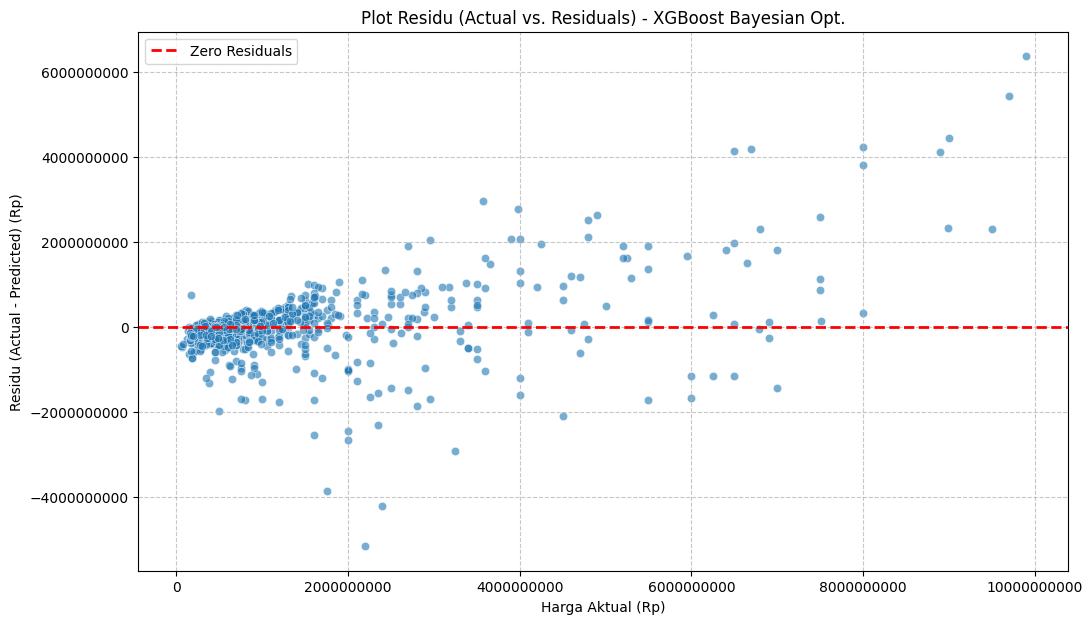

✅ Visualisasi residu selesai.


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

print("📈 Memulai visualisasi residu model...")

# Gunakan model terbaik dari Bayesian Optimization
# best_xgb_model_bayes sudah dilatih sebelumnya

# Prediksi pada data test menggunakan model terbaik
y_pred_best_bayes = best_xgb_model_bayes.predict(X_test_c)

# Hitung Residu (Actual - Predicted)
residuals = y_test_c - y_pred_best_bayes

plt.figure(figsize=(12, 7))
sns.scatterplot(x=y_test_c, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2, label='Zero Residuals')
plt.title('Plot Residu (Actual vs. Residuals) - XGBoost Bayesian Opt.')
plt.xlabel('Harga Aktual (Rp)')
plt.ylabel('Residu (Actual - Predicted) (Rp)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='x') # Mematikan notasi ilmiah untuk sumbu x
plt.ticklabel_format(style='plain', axis='y') # Mematikan notasi ilmiah untuk sumbu y
plt.legend()
plt.show()

print("✅ Visualisasi residu selesai.")

In [37]:
import joblib
joblib.dump(best_xgb_model_bayes_log, 'xgb_model.joblib')

['xgb_model.joblib']

### Identifikasi Model Terbaik

Berdasarkan ringkasan perbandingan performa model yang telah dilakukan, kita dapat melihat bahwa:

*   **XGBoost (setelah Bayesian Optimization & Log-Transform)** memiliki **MAE terendah sebesar Rp 447,217,384** dan **MedAE terendah sebesar Rp 203,831,600**.
*   Model ini menunjukkan peningkatan signifikan dibandingkan semua model lain, termasuk XGBoost tanpa transformasi logaritmik dan tanpa binning.

Oleh karena itu, model `best_xgb_model_bayes_log` yang dihasilkan dari *Bayesian Optimization* dengan transformasi logaritmik pada variabel target (`Harga_Clean`) adalah model terbaik yang akan digunakan untuk *deployment*. Transformasi logaritmik berhasil mengatasi distribusi yang miring pada harga dan membuat model bekerja lebih efisien, terbukti dengan penurunan MAE dan MedAE yang signifikan.